# PEMS08 — GCN + Transformer (Beat Paper MAE=13.114)

## Why all previous models failed
Every model we tried (LSTM, TCN, CNN, Transformer) treated 170 sensors as
independent channels. **They never modelled sensor-to-sensor relationships.**

Traffic at sensor A affects sensor B 2 minutes later — that's the key signal.
This requires a **Graph Convolutional Network (GCN)** on the road topology.

## Architecture (inspired by paper Table V baseline STFGCN: MAE=13.618)
```
Input: (B, 12, 170, 3)  — time x sensors x features
  |
  [Spatial GCN]  — message passing over sensor graph
   A_dist: sensor distance adjacency (from coordinates or correlation)
   A_dyna: learned dynamic adjacency
   GCN(X, A) = ReLU(A_hat @ X @ W)
  |
  [Temporal Transformer]  — self-attention over 12 timesteps
   4 layers, nhead=8, Pre-LN
  |
  FC -> (B, 1, 170)
```
Target: MAE < 13.114 (beat MD-GRTN from paper)

In [1]:
from google.colab import files
uploaded  = files.upload()
DATA_PATH = list(uploaded.keys())[0]

# Option B:
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_PATH = '/content/drive/MyDrive/PEMS08.npz'

Saving PEMS08.npz to PEMS08.npz


In [2]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [3]:
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import math
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

In [4]:
data  = np.load(DATA_PATH)
arr   = data['data'].astype(np.float32)   # (T, 170, 3)
print('Shape:', arr.shape)
N_SENS = arr.shape[1]   # 170
N_FEAT = arr.shape[2]   # 3
print(f'Sensors: {N_SENS} | Features: {N_FEAT}')

Shape: (17856, 170, 3)
Sensors: 170 | Features: 3


In [5]:
# ── Normalise per-feature ────────────────────────────────────────────────────
train_end = int(0.8 * len(arr))
feat_mean = arr[:train_end].mean(axis=0, keepdims=True)   # (1, 170, 3)
feat_std  = arr[:train_end].std(axis=0,  keepdims=True) + 1e-8
arr_norm  = (arr - feat_mean) / feat_std                  # (T, 170, 3)

# Flow stats for denormalisation
tgt_mean = feat_mean[0, :, 0]   # (170,) per-sensor flow mean
tgt_std  = feat_std [0, :, 0]   # (170,) per-sensor flow std
print('Normalised. Flow mean range:', tgt_mean.min().round(1), '-', tgt_mean.max().round(1))

Normalised. Flow mean range: 9.4 - 461.2


In [6]:
# ── Build dynamic adjacency from correlation ─────────────────────────────────
# Use training data flow correlations as graph edges
flow_train = arr_norm[:train_end, :, 0]   # (T_train, 170)
corr = np.corrcoef(flow_train.T)          # (170, 170) sensor correlation matrix
corr = np.clip(corr, 0, 1)               # keep only positive correlations

# Threshold: keep top connections only
threshold = np.percentile(corr, 80)       # top 20% connections
adj = (corr > threshold).astype(np.float32)
np.fill_diagonal(adj, 1)                  # self-loops

# Normalise adjacency: D^(-1/2) A D^(-1/2)
deg   = adj.sum(axis=1)
d_inv = np.power(deg, -0.5)
d_inv[np.isinf(d_inv)] = 0
D_inv = np.diag(d_inv)
adj_norm = D_inv @ adj @ D_inv

A = torch.FloatTensor(adj_norm).to('cpu')  # will move to device in model
print(f'Adjacency matrix: {adj.shape}  avg connections per node: {adj.sum(1).mean():.1f}')

Adjacency matrix: (170, 170)  avg connections per node: 34.0


In [7]:
SEQ_LEN  = 12
PRED_LEN = 1

# X shape: (N, 12, 170, 3)   Y shape: (N, 1, 170)
X_list, Y_list = [], []
flow_norm = arr_norm[:, :, 0]   # (T, 170)

for i in range(len(arr_norm) - SEQ_LEN - PRED_LEN + 1):
    X_list.append(arr_norm [i           : i + SEQ_LEN])        # (12, 170, 3)
    Y_list.append(flow_norm[i + SEQ_LEN : i + SEQ_LEN + PRED_LEN])  # (1, 170)

X_all = np.array(X_list, dtype=np.float32)  # (N, 12, 170, 3)
Y_all = np.array(Y_list, dtype=np.float32)  # (N,  1, 170)

split     = int(0.8 * len(X_all))
val_split = int(0.9 * split)

X_train, Y_train = X_all[:val_split],       Y_all[:val_split]
X_val,   Y_val   = X_all[val_split:split],  Y_all[val_split:split]
X_test,  Y_test  = X_all[split:],           Y_all[split:]

print(f'Train {X_train.shape} | Val {X_val.shape} | Test {X_test.shape}')

Train (12847, 12, 170, 3) | Val (1428, 12, 170, 3) | Test (3569, 12, 170, 3)


In [8]:
class TrafficDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X)   # (N, 12, 170, 3)
        self.Y = torch.from_numpy(Y)   # (N,  1, 170)
    def __len__(self):          return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.Y[idx]

BATCH = 64
train_loader = DataLoader(TrafficDataset(X_train, Y_train), batch_size=BATCH, shuffle=True,  pin_memory=True, num_workers=2)
val_loader   = DataLoader(TrafficDataset(X_val,   Y_val),   batch_size=BATCH, shuffle=False, pin_memory=True, num_workers=2)
test_loader  = DataLoader(TrafficDataset(X_test,  Y_test),  batch_size=BATCH, shuffle=False, pin_memory=True, num_workers=2)

In [9]:
# ── GCN layer ────────────────────────────────────────────────────────────────
class GraphConv(nn.Module):
    """Single GCN layer: H = ReLU(A_hat @ X @ W)"""
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W = nn.Linear(in_dim, out_dim, bias=False)

    def forward(self, x, adj):   # x: (B, N, F)  adj: (N, N)
        # Spatial message passing: each node aggregates neighbours
        h = torch.bmm(adj.unsqueeze(0).expand(x.size(0), -1, -1), x)  # (B,N,F)
        return F.relu(self.W(h))


# ── Positional Encoding ───────────────────────────────────────────────────────
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.drop(x + self.pe[:, :x.size(1)])


# ── Full GCN + Transformer model ──────────────────────────────────────────────
class GCNTransformer(nn.Module):
    """
    Input:  (B, 12, 170, 3)
    Output: (B, 1,  170)

    Step 1: GCN over sensor graph at each timestep  -> spatial features
    Step 2: Transformer over time                   -> temporal features
    Step 3: FC to output
    """
    def __init__(self, n_sensors=170, n_feat=3, d_model=128,
                 gcn_hidden=64, nhead=8, tf_layers=4,
                 ffn_dim=512, dropout=0.1, pred_len=1):
        super().__init__()
        self.pred_len  = pred_len
        self.n_sensors = n_sensors
        self.d_model   = d_model

        # GCN: 2 layers, input=n_feat, output=gcn_hidden
        self.gcn1 = GraphConv(n_feat,      gcn_hidden)
        self.gcn2 = GraphConv(gcn_hidden,  gcn_hidden)

        # Project GCN output (170 * gcn_hidden) to d_model for Transformer
        self.proj = nn.Linear(n_sensors * gcn_hidden, d_model)

        # Transformer encoder over time steps
        self.pos_enc = PositionalEncoding(d_model, dropout=dropout)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=ffn_dim, dropout=dropout,
            batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=tf_layers)

        self.norm = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(d_model, n_sensors * pred_len)

    def forward(self, x, adj):            # x: (B, 12, 170, 3)
        B, T, N, F = x.shape

        # Apply GCN at every timestep
        gcn_out = []
        for t in range(T):
            h = self.gcn1(x[:, t, :, :], adj)   # (B, 170, gcn_hidden)
            h = self.gcn2(h, adj)                # (B, 170, gcn_hidden)
            gcn_out.append(h.reshape(B, -1))     # (B, 170*gcn_hidden)
        gcn_out = torch.stack(gcn_out, dim=1)    # (B, 12, 170*gcn_hidden)

        # Project to d_model
        z = self.proj(gcn_out)                   # (B, 12, d_model)

        # Temporal Transformer
        z = self.pos_enc(z)
        z = self.transformer(z)                  # (B, 12, d_model)
        z = self.norm(z.mean(dim=1))             # (B, d_model)

        out = self.fc(self.drop(z))              # (B, 170*pred_len)
        return out.view(B, self.pred_len, self.n_sensors)


A_device = A.to(device)

model = GCNTransformer(
    n_sensors=N_SENS, n_feat=N_FEAT, d_model=128,
    gcn_hidden=64, nhead=8, tf_layers=4,
    ffn_dim=512, dropout=0.1, pred_len=PRED_LEN
).to(device)

total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parameters: {total:,}')

with torch.no_grad():
    dummy = torch.zeros(2, SEQ_LEN, N_SENS, N_FEAT).to(device)
    print(f'Output shape: {tuple(model(dummy, A_device).shape)}')

/tmp/ipykernel_345/1750515241.py:62: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc_layer, num_layers=tf_layers)


Parameters: 2,212,330
Output shape: (2, 1, 170)


In [10]:
criterion = nn.HuberLoss(delta=1.0)   # paper uses Huber loss
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
)

EPOCHS=100; patience=15
best_val=float('inf'); p_counter=0
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train(); tloss=0.0
    for x, y in train_loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        optimizer.zero_grad()
        loss = criterion(model(x, A_device), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tloss += loss.item()
    tloss /= len(train_loader)
    train_losses.append(tloss)

    model.eval(); vloss=0.0
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            vloss += criterion(model(x, A_device), y).item()
    vloss /= len(val_loader)
    val_losses.append(vloss)

    scheduler.step(vloss)
    lr  = optimizer.param_groups[0]['lr']
    gap = vloss - tloss
    print(f'Epoch {epoch+1:3d} | Train {tloss:.4f} | Val {vloss:.4f} | Gap {gap:.4f} | LR {lr:.2e}')

    if vloss < best_val:
        best_val=vloss; p_counter=0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        p_counter += 1
    if p_counter >= patience:
        print('Early stopping'); break

model.load_state_dict(torch.load('best_model.pth'))
print('Best model loaded!')

Epoch   1 | Train 0.0920 | Val 0.0938 | Gap 0.0018 | LR 1.00e-03
Epoch   2 | Train 0.0475 | Val 0.0835 | Gap 0.0359 | LR 1.00e-03
Epoch   3 | Train 0.0398 | Val 0.0791 | Gap 0.0393 | LR 1.00e-03
Epoch   4 | Train 0.0366 | Val 0.0719 | Gap 0.0353 | LR 1.00e-03
Epoch   5 | Train 0.0346 | Val 0.0683 | Gap 0.0337 | LR 1.00e-03
Epoch   6 | Train 0.0334 | Val 0.0660 | Gap 0.0326 | LR 1.00e-03
Epoch   7 | Train 0.0325 | Val 0.0651 | Gap 0.0327 | LR 1.00e-03
Epoch   8 | Train 0.0320 | Val 0.0643 | Gap 0.0323 | LR 1.00e-03
Epoch   9 | Train 0.0314 | Val 0.0632 | Gap 0.0318 | LR 1.00e-03
Epoch  10 | Train 0.0311 | Val 0.0653 | Gap 0.0342 | LR 1.00e-03
Epoch  11 | Train 0.0308 | Val 0.0645 | Gap 0.0337 | LR 1.00e-03
Epoch  12 | Train 0.0304 | Val 0.0636 | Gap 0.0332 | LR 1.00e-03
Epoch  13 | Train 0.0301 | Val 0.0619 | Gap 0.0318 | LR 1.00e-03
Epoch  14 | Train 0.0297 | Val 0.0620 | Gap 0.0323 | LR 1.00e-03
Epoch  15 | Train 0.0296 | Val 0.0627 | Gap 0.0331 | LR 1.00e-03
Epoch  16 | Train 0.0293 

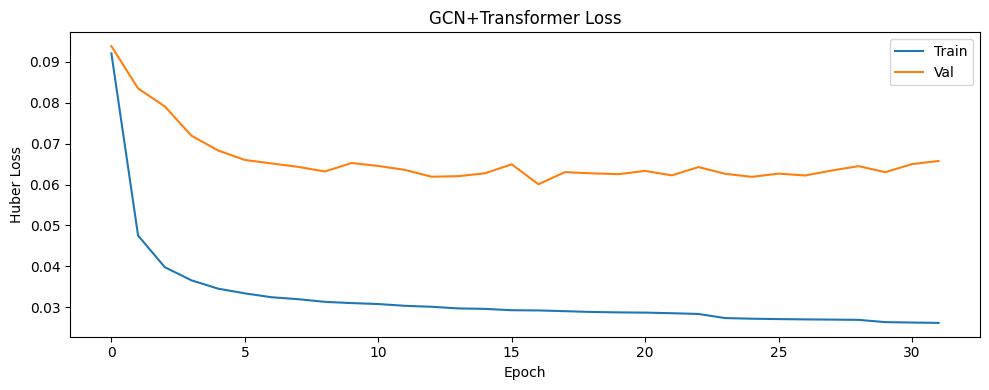

Final gap: 0.0395


In [11]:
plt.figure(figsize=(10,4))
plt.plot(train_losses, label='Train'); plt.plot(val_losses, label='Val')
plt.xlabel('Epoch'); plt.ylabel('Huber Loss')
plt.title('GCN+Transformer Loss'); plt.legend(); plt.tight_layout(); plt.show()
print(f'Final gap: {val_losses[-1]-train_losses[-1]:.4f}')

Actual range: -0.0 to 848.0
MAE:  18.8625   (paper MD-GRTN: 13.114  target: <13.114)
RMSE: 28.9334  (paper MD-GRTN: 22.623)
MAPE: 11.3363% (paper MD-GRTN:  8.471%)


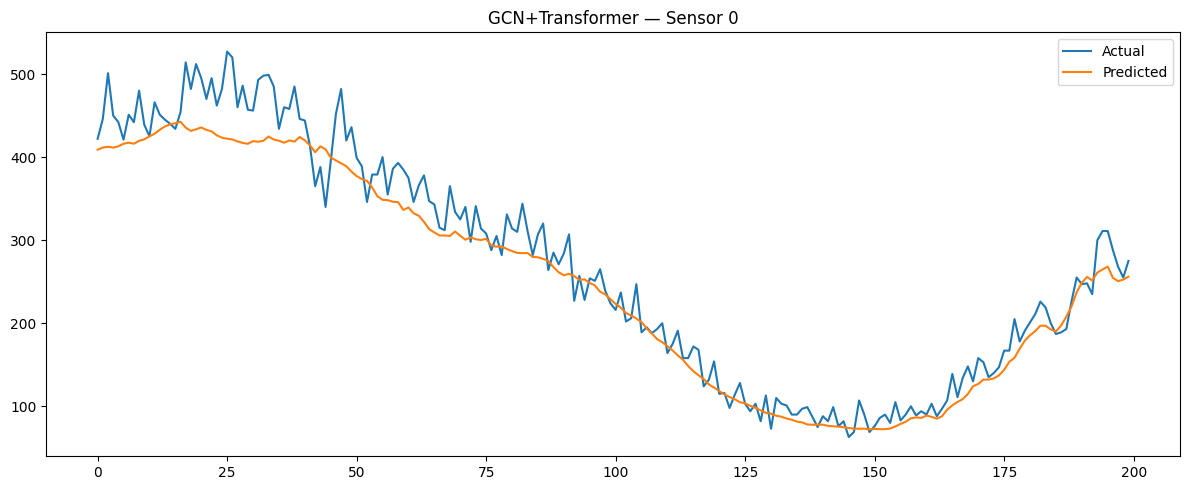

In [12]:
model.eval()
preds, actual = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device, non_blocking=True)
        preds.append(model(x, A_device).cpu().numpy())
        actual.append(y.numpy())

preds  = np.concatenate(preds)    # (N, 1, 170) normalised
actual = np.concatenate(actual)   # (N, 1, 170) normalised

# Per-sensor denormalisation
preds  = preds  * tgt_std[None, None, :] + tgt_mean[None, None, :]
actual = actual * tgt_std[None, None, :] + tgt_mean[None, None, :]

print(f'Actual range: {actual.min():.1f} to {actual.max():.1f}')

mae  = mean_absolute_error(actual.reshape(-1), preds.reshape(-1))
rmse = np.sqrt(mean_squared_error(actual.reshape(-1), preds.reshape(-1)))
mask = actual.reshape(-1) > 1.0
mape = np.mean(np.abs((actual.reshape(-1)[mask]-preds.reshape(-1)[mask])/
                       actual.reshape(-1)[mask]))*100

print(f'MAE:  {mae:.4f}   (paper MD-GRTN: 13.114  target: <13.114)')
print(f'RMSE: {rmse:.4f}  (paper MD-GRTN: 22.623)')
print(f'MAPE: {mape:.4f}% (paper MD-GRTN:  8.471%)')

plt.figure(figsize=(12,5))
plt.plot(actual[:200,0,0], label='Actual')
plt.plot(preds[:200, 0,0], label='Predicted')
plt.legend(); plt.title('GCN+Transformer — Sensor 0')
plt.tight_layout(); plt.show()